In [23]:
# ============================================================
# CELL 1 — GPU Check
# ============================================================
import torch
print("="*50)
print("GPU CHECK")
print("="*50)
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Device name: {torch.cuda.get_device_name(0)}")
print("="*50)

GPU CHECK
CUDA available: True
Device name: Tesla P100-PCIE-16GB


In [24]:
# ============================================================
# CELL 2 — Environment
# ============================================================
import os
os.environ['PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION'] = 'python'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import warnings
warnings.filterwarnings('ignore')

In [25]:
# ============================================================
# CELL 3 — Imports
# ============================================================
import pandas as pd
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
from datasets import load_dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
)
from sklearn.metrics import (
    accuracy_score, f1_score, cohen_kappa_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

In [26]:
# ============================================================
# CELL 4 — Paths  
# ============================================================
MODEL_NAME = "aubmindlab/bert-base-arabertv2"
path       = "/kaggle/input/datasets/feryaljadallah/refinedbayyin/Refined_Bayyin_Dataset.csv"

OUTPUT_DIR = "/kaggle/working/runs/AraBERTv2"
SAVE_DIR   = "/kaggle/working/AraBERTv2_RefinedBayyin"

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(SAVE_DIR,   exist_ok=True)

In [27]:
# ============================================================
# CELL 5 — Hyperparameters
# ============================================================
TEXT_COL  = "Sentence"
LABEL_COL = "Readability_Level"
LEVELS    = [1, 2, 3, 4, 5, 6]
LR        = 5e-5
BATCH     = 64
EPOCHS    = 6
MAX_LEN   = 128
SEED      = 42

In [28]:
# ============================================================
# CELL 6 — Data loading & split
# ============================================================
print("\nLoading dataset...")
dataset    = load_dataset("csv", data_files={"train": path}, split="train")
print(f"Dataset size: {len(dataset)}")

# 70 / 20 / 10 split — identical to original
train_test = dataset.train_test_split(test_size=0.3, seed=SEED)
test_valid = train_test["test"].train_test_split(test_size=1/3, seed=SEED)

splits = DatasetDict({
    "train":      train_test["train"],
    "test":       test_valid["train"],
    "validation": test_valid["test"],
})
print(f"Train: {len(splits['train'])} | Test: {len(splits['test'])} | Val: {len(splits['validation'])}")

# Label mapping
level2id = {lvl: i for i, lvl in enumerate(LEVELS)}   # {1:0, 2:1, ..., 6:5}
id2level = {i: lvl for lvl, i in level2id.items()}

def map_labels(ds):
    return ds.map(lambda ex: {"labels": level2id[int(ex[LABEL_COL])]})

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


Loading dataset...
Dataset size: 44917
Train: 31441 | Test: 8984 | Val: 4492


In [29]:
# ============================================================
# CELL 7 — Metrics
# ============================================================
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds    = np.argmax(logits, axis=1)
    acc      = accuracy_score(labels, preds)
    macro_f1 = f1_score(labels, preds, average="macro")
    qwk      = cohen_kappa_score(labels, preds, weights="quadratic")
    return {"accuracy": acc, "macro_f1": macro_f1, "qwk": qwk}

In [30]:
# ============================================================
# CELL 8 — Ordinal-Aware Trainer
# ============================================================
class OrdinalAwareTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.pop("labels")
        outputs = model(**inputs)
        logits  = outputs.get("logits")
        probs   = torch.softmax(logits, dim=-1)

        # Hard-example weighting
        true_probs        = probs.gather(1, labels.unsqueeze(1)).squeeze()
        difficulty_weight = (1.0 - true_probs.detach()) + 0.5
        difficulty_weight = difficulty_weight / difficulty_weight.mean()

        # Ordinal distance penalty
        K            = logits.shape[-1]
        indices      = torch.arange(K).float().to(logits.device)
        labels_float = labels.float().unsqueeze(1)
        dist         = torch.abs(indices - labels_float)
        soft_targets = torch.exp(-dist / 2.0)
        soft_targets = soft_targets / soft_targets.sum(dim=1, keepdim=True)

        ce_loss      = F.cross_entropy(logits, labels, reduction="none")
        weighted_ce  = ce_loss * difficulty_weight
        log_probs    = F.log_softmax(logits, dim=-1)
        ordinal_loss = F.kl_div(log_probs, soft_targets, reduction="none").sum(dim=1)

        final_loss = (weighted_ce + 0.3 * ordinal_loss).mean()
        return (final_loss, outputs) if return_outputs else final_loss



In [31]:
# ============================================================
# CELL 9 — Evaluation helpers
# ============================================================
def eval_and_report(ds, name, trainer_obj):
    out   = trainer_obj.predict(ds)
    preds = out.predictions.argmax(-1)
    print(f"\n{'='*60}\n{name} Metrics\n{'='*60}")
    print(out.metrics)
    target_names = [f"L{lvl}" for lvl in LEVELS]
    print("\nPer-class F1:")
    print(classification_report(ds["labels"], preds, target_names=target_names, digits=4))

def plot_confusion_matrix_normalized(ds, trainer_obj, title_suffix="AraBERT"):
    out    = trainer_obj.predict(ds)
    y_true = ds["labels"]
    y_pred = out.predictions.argmax(-1)
    cm     = confusion_matrix(y_true, y_pred, normalize="true")
    disp   = ConfusionMatrixDisplay(cm, display_labels=[str(lvl) for lvl in LEVELS])
    fig, ax = plt.subplots(figsize=(7, 6))
    disp.plot(cmap="Blues", values_format=".2f", ax=ax, colorbar=True)
    plt.title(f"Normalized Confusion Matrix - {title_suffix}")
    plt.tight_layout()
    plt.savefig(f"/kaggle/working/cm_{title_suffix}.png", dpi=150)
    plt.show()

In [32]:
# ============================================================
# CELL 10 — Training function  (all fixes applied here)
# ============================================================
def train_model(text_col, output_dir, save_dir, model_name="Model"):
    print(f"\n{'#'*60}")
    print(f"# TRAINING: {model_name}  |  text_col: {text_col}")
    print(f"{'#'*60}\n")

    def tokenize_fn_custom(batch):
        return tokenizer(batch[text_col], truncation=True,
                         padding="max_length", max_length=MAX_LEN)

    train_ds = map_labels(splits["train"]).map(tokenize_fn_custom, batched=True)
    val_ds   = map_labels(splits["validation"]).map(tokenize_fn_custom, batched=True)
    test_ds  = map_labels(splits["test"]).map(tokenize_fn_custom, batched=True)

    cols = ["input_ids", "attention_mask", "labels"]
    train_ds.set_format(type="torch", columns=cols)
    val_ds.set_format(type="torch",   columns=cols)
    test_ds.set_format(type="torch",  columns=cols)

    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=len(LEVELS)
    )

    args = TrainingArguments(
        output_dir=output_dir,
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="epoch",
        learning_rate=LR,
        per_device_train_batch_size=BATCH,
        per_device_eval_batch_size=BATCH,
        num_train_epochs=EPOCHS,
        weight_decay=0.01,
        warmup_ratio=0.1,
        load_best_model_at_end=True,
        metric_for_best_model="qwk",
        greater_is_better=True,
        seed=SEED,
        report_to="none",
        save_total_limit=EPOCHS,   
        fp16=torch.cuda.is_available(),
    )

    trainer = OrdinalAwareTrainer(
        model=model,
        args=args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        compute_metrics=compute_metrics,
    )

    trainer.train()

    print(f"\nBest checkpoint: {trainer.state.best_model_checkpoint}")
    print(f"Best QWK:        {trainer.state.best_metric:.4f}")
    print(f"Saving best model to: {save_dir}")
    trainer.save_model(save_dir)
    tokenizer.save_pretrained(save_dir)
    print("✓ Model and tokenizer saved successfully!")

    # Evaluate on test set
    print("\nEvaluating on Test Set...")
    eval_and_report(test_ds, f"Test {model_name}", trainer)
    plot_confusion_matrix_normalized(test_ds, trainer, title_suffix=model_name)

    return trainer, test_ds


############################################################
# TRAINING: AraBERTv2  |  text_col: D3Tok
############################################################



Map:   0%|          | 0/8984 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: aubmindlab/bert-base-arabertv2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Qwk
1,1.251891,1.066033,0.740427,0.731894,0.847412
2,0.933949,0.947707,0.792520,0.787877,0.883543
3,0.776619,1.003446,0.802315,0.799539,0.890674
4,0.631034,1.090734,0.798531,0.794804,0.888592
5,0.521560,1.175555,0.806545,0.804316,0.887511
6,0.456116,1.207222,0.803428,0.801556,0.888993


...

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


Best checkpoint: /kaggle/working/runs/AraBERTv2/checkpoint-1476
Best QWK:        0.8907
Saving best model to: /kaggle/working/AraBERTv2_RefinedBayyin


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✓ Model and tokenizer saved successfully!

Evaluating on Test Set...



Test AraBERTv2 Metrics
{'test_loss': 1.028151512145996, 'test_accuracy': 0.7955253784505788, 'test_macro_f1': 0.7918709949007326, 'test_qwk': 0.8851113467652967, 'test_runtime': 31.3304, 'test_samples_per_second': 286.75, 'test_steps_per_second': 4.5}

Per-class F1:
              precision    recall  f1-score   support

          L1     0.7387    0.8374    0.7849      1519
          L2     0.7550    0.7120    0.7329      1528
          L3     0.7688    0.8012    0.7847      1353
          L4     0.6983    0.6249    0.6596      1437
          L5     0.8517    0.9275    0.8880      1530
          L6     0.9500    0.8571    0.9012      1617

    accuracy                         0.7955      8984
   macro avg     0.7937    0.7934    0.7919      8984
weighted avg     0.7968    0.7955    0.7945      8984



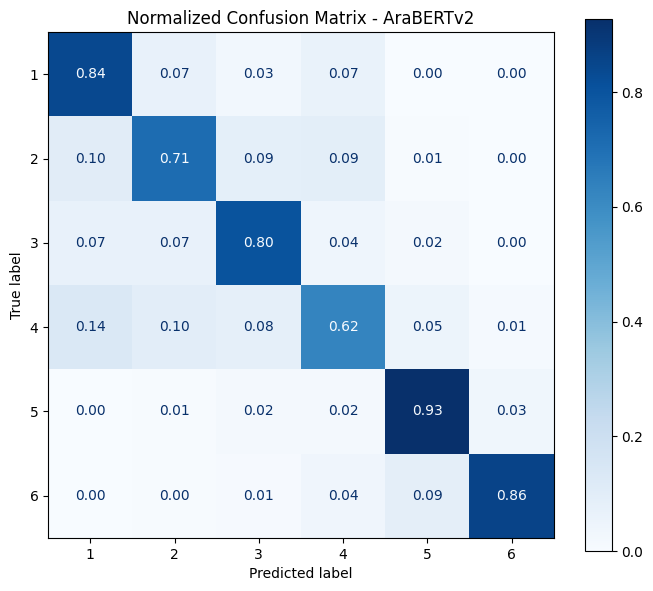


FINAL RESULTS
AraBERTv2
  Accuracy: 0.7955
  Macro F1: 0.7919
  QWK:      0.8851

Model saved to: /kaggle/working/AraBERTv2_RefinedBayyin


In [33]:
# ============================================================
# CELL 11 — Run training
# ============================================================
trainer_arabert, test_ds = train_model(
    text_col   = "D3Tok",
    output_dir = OUTPUT_DIR,
    save_dir   = SAVE_DIR,
    model_name = "AraBERTv2"
)

# Final evaluation
results = {"AraBERTv2": trainer_arabert.evaluate(test_ds)}

print("\n" + "="*60)
print("FINAL RESULTS")
print("="*60)
for name, metrics in results.items():
    print(f"{name}")
    print(f"  Accuracy: {metrics.get('eval_accuracy', 0):.4f}")
    print(f"  Macro F1: {metrics.get('eval_macro_f1', 0):.4f}")
    print(f"  QWK:      {metrics.get('eval_qwk', 0):.4f}")
print(f"\nModel saved to: {SAVE_DIR}")
print("="*60)

In [34]:
import shutil
from IPython.display import FileLink

shutil.make_archive('AraBERTv2_RefinedBayyin', 'zip', SAVE_DIR)
FileLink('AraBERTv2_RefinedBayyin.zip')

/kaggle/working/AraBERTv2_RefinedBayyin.zip